In [93]:
from matplotlib import pyplot as plt
import numpy as np
import PIL

In [94]:
img = plt.imread('images.jpg')

In [95]:
print(f'Image size: {img.shape[:2]}')
print(f'Image dimensions: {img.shape}')
print(f'Dimensions: {img.ndim}')
print(f'Data type: {img.dtype}')
print(f'Pixel range: {img.min()}-{img.max()}')

Image size: (680, 450)
Image dimensions: (680, 450, 3)
Dimensions: 3
Data type: uint8
Pixel range: 0-255


In [96]:
#image grayscale conversion
def grayscale(image):
    img_arr = np.array(image)
    grayscale_arr =np.array([0.299, 0.587, 0.114])#(1,1,3)
    gray_img_arr = (img_arr * grayscale_arr).sum(axis=2).astype(np.uint8)
    gray_img = PIL.Image.fromarray(gray_img_arr)
    gray_img.save('1.png')

grayscale(img)

gray_img = PIL.Image.open('1.png')

In [97]:
#brigthness
def adjust_brightness(image, value):
    img_arr = np.array(image).astype('int64')
    x = img_arr + value
    bright_img_arr = np.clip(x, 0, 255).astype(np.uint8)
    bright_img = PIL.Image.fromarray(bright_img_arr)
    bright_img.save('2.png')

adjust_brightness(img, 50)
brighter_img = PIL.Image.open('2.png')

In [98]:
#contrast
def adjust_contrast(image, factor):
    img_arr = np.array(image)
    x = 127.5 + factor * (img_arr - 127.5)
    contrast_limit = np.clip(x, 0, 255).astype(np.uint8)
    contrast_img = PIL.Image.fromarray(contrast_limit)
    contrast_img.save('3.png')

adjust_contrast(gray_img, 2)
contrasted_img = PIL.Image.open('3.png')

In [99]:
#cropping
def crop(image, y1, y2, x1, x2):
    img_arr = np.array(image)
    cropped = img_arr[y1:(y2 + 1), x1:(x2 + 1), :]
    cropped_img = PIL.Image.fromarray(cropped)
    cropped_img.save('4.png')

crop(img, 10, 200, 135, 300)
crop_img = PIL.Image.open('4.png')

In [100]:
#Horizontal Flip
def horizontal_flip(image):
    img_arr = np.array(image)
    flip_arr = img_arr[:, ::-1, :]
    flipped = PIL.Image.fromarray(flip_arr)
    flipped.save('5.png')

horizontal_flip(img)
flipped_img1 = PIL.Image.open('5.png')

In [101]:
#Vertical Flip
def Vertical_flip(image):
    img_arr = np.array(image)
    flip_arr = img_arr[::-1, :, :]
    flipped = PIL.Image.fromarray(flip_arr)
    flipped.save('6.png')

Vertical_flip(img)
flipped_img2 = PIL.Image.open('6.png')

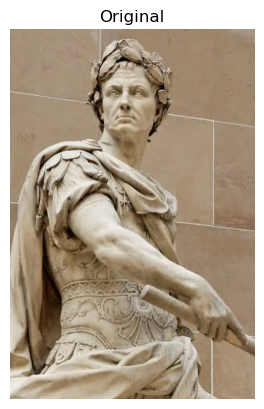

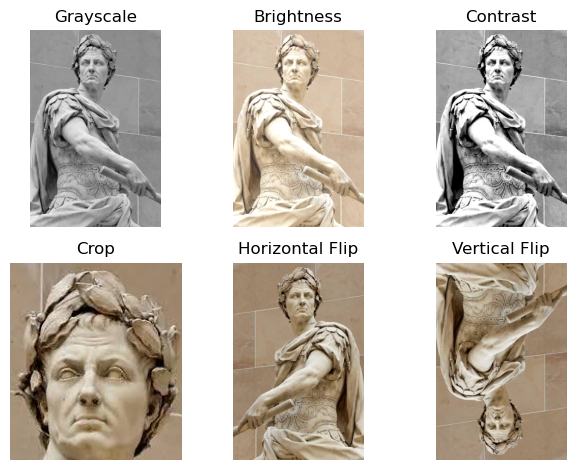

In [102]:
#Application
plt.imshow(img)
plt.axis('off')
plt.title('Original')

figure, axes = plt.subplots(2,3)

axes[0,0].imshow(gray_img, cmap='gray')
axes[0,1].imshow(brighter_img)
axes[0,2].imshow(contrasted_img, cmap='gray')
axes[1,0].imshow(crop_img)
axes[1,1].imshow(flipped_img1)
axes[1,2].imshow(flipped_img2)

axes[0,0].set_title('Grayscale')
axes[0,1].set_title('Brightness')
axes[0,2].set_title('Contrast')
axes[1,0].set_title('Crop')
axes[1,1].set_title('Horizontal Flip')
axes[1,2].set_title('Vertical Flip')

for ax in axes.flat: #axes.flat makes the axes 1D array so that it becomes easy to iterate
    ax.axis('off')


plt.tight_layout()
plt.show()